# 07 — Ablation Study: ISPNet Components + KAN Variants (Daily 168→24)

Isolates contribution of each design choice and tests KAN head variants.

| Variant | RevIN | Head | Tests |
|---------|-------|------|-------|
| **A — GRU_base** | None | MLP | No normalization |
| **B — GRU_stdRevIN** | Standard | MLP | RevIN over all timesteps |
| **C — ISPNet** | Mask-Aware | MLP | RevIN on observed only |
| **D — ISPNet_FourierKAN** | Mask-Aware | FourierKAN | Fourier basis for periodicity |
| **E — ISPNet_ChebyKAN** | Mask-Aware | ChebyKAN | Chebyshev polynomial head |

All variants: GRU enc-dec, hidden=64, dropout=0.4, wd=2e-3, EntityBias, 3 seeds.


In [1]:
import warnings, json, time, os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────
SEED  = 42
SEEDS = [42, 123, 2024]

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
seed_everything(SEED)

# ── Paths ───────────────────────────────────────────────────────────
_CANDIDATES = [
    Path("/kaggle/input/cesnet-timeseries24-preprocessed"),
    Path("/kaggle/input/datasets/nguynvntnpht/cesnet-timeseries24-preprocessed"),
    Path("../preprocessed"),
]
PREPROCESSED_ROOT = next(p for p in _CANDIDATES if p.exists())
_ON_KAGGLE    = Path("/kaggle/working").exists()
RESULTS_ROOT  = Path("/kaggle/working/results/daily/ablation") if _ON_KAGGLE else Path("../results/daily/ablation")
DL_RESULTS_ROOT = Path("/kaggle/working/results/daily/baselines") if _ON_KAGGLE else Path("../results/daily/baselines")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Data  : {PREPROCESSED_ROOT}")
print(f"Output: {RESULTS_ROOT}")
print(f"Device: {DEVICE}  |  seeds={SEEDS}")

# ── Split constants ──────────────────────────────────────────────────
TRAIN_END    = 2352
VAL_END      = 2688
OUTAGE_START = 5376
OUTAGE_END   = 5903
TOTAL_SLOTS  = 6718

# ── Window config ───────────────────────────────────────────────────
ENC_LEN    = 168
PRED_LEN   = 24
TRAIN_STEP = 24

# ── Optimizer (same as nb 06 / 07 GRU baseline) ─────────────────────
LR            = 1e-3
LR_MIN        = 1e-5
GRAD_CLIP     = 1.0
MAX_EPOCHS    = 80
WARMUP_EPOCHS = 5
PATIENCE      = 10
MIN_DELTA     = 1e-4
BATCH_SIZE    = 64
AUG_NOISE_STD = 0.06

# ── Feature columns (same as nb 06) ─────────────────────────────────
ENC_FEATURES = [
    "n_bytes_scaled", "observed_mask", "gap_since_last_obs", "is_gap_start",
    "sin_hour", "cos_hour", "sin_dow", "cos_dow", "is_weekend", "is_holiday",
]
DEC_FEATURES = [
    "sin_hour", "cos_hour", "sin_dow", "cos_dow", "is_weekend", "is_holiday",
    "lag24_bytes", "lag24_mask", "lag168_bytes", "lag168_mask",
]
N_ENC, N_DEC = len(ENC_FEATURES), len(DEC_FEATURES)

# ── Shared backbone config ───────────────────────────────────────────
BACKBONE_CFG = {"hidden": 64, "n_layers": 2, "dropout": 0.4, "wd": 2e-3}

# ── Ablation variants ────────────────────────────────────────────────
VARIANTS = [
    {"name": "GRU_base",          "revin_mode": "none",       "head_type": "mlp",         "label": "A — GRU (no RevIN)"},
    {"name": "GRU_stdRevIN",      "revin_mode": "standard",   "head_type": "mlp",         "label": "B — GRU + Standard RevIN"},
    {"name": "ISPNet",            "revin_mode": "mask_aware", "head_type": "mlp",         "label": "C — ISPNet (Mask-Aware RevIN)"},
    {"name": "ISPNet_FourierKAN", "revin_mode": "mask_aware", "head_type": "fourier_kan", "label": "D — ISPNet + FourierKAN"},
    {"name": "ISPNet_ChebyKAN",   "revin_mode": "mask_aware", "head_type": "cheby_kan",   "label": "E — ISPNet + ChebyKAN"},
]

print(f"\nAblation variants:")
for v in VARIANTS:
    print(f"  {v['label']}  (revin_mode='{v['revin_mode']}')") 

Data  : /kaggle/input/datasets/nguynvntnpht/cesnet-timeseries24-preprocessed
Output: /kaggle/working/results/ablation
Device: cuda  |  seeds=[42, 123, 2024]

Ablation variants:
  A — GRU (no RevIN)  (revin_mode='none')
  B — GRU + Standard RevIN  (revin_mode='standard')
  C — ISPNet (Mask-Aware RevIN)  (revin_mode='mask_aware')
  D — ISPNet + FourierKAN  (revin_mode='mask_aware')
  E — ISPNet + ChebyKAN  (revin_mode='mask_aware')


In [2]:
# ── Load panel + build per-entity arrays ─────────────────────────────
LOAD_COLS = [
    "id_institution", "id_time",
    "n_bytes", "n_bytes_log1p", "n_bytes_scaled",
    "observed_mask", "gap_since_last_obs", "is_gap_start",
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "is_weekend", "is_holiday",
]

panel = pd.read_parquet(PREPROCESSED_ROOT / "panel_institutions.parquet", columns=LOAD_COLS)
print(f"Loaded: {panel.shape}   entities: {panel['id_institution'].nunique()}")

entity_enc  = {}
entity_dec  = {}
entity_raw  = {}
entity_mask = {}
entity_inv  = {}
full_idx    = pd.RangeIndex(TOTAL_SLOTS)

import pickle as _pkl
_scaler_pkl = PREPROCESSED_ROOT / "scalers/scalers_institutions.pkl"
if _scaler_pkl.exists():
    with open(_scaler_pkl, "rb") as _f:
        _scalers = _pkl.load(_f)
    _scaler_inv = {eid: (float(sc.center_[0]), float(sc.scale_[0]))
                   for eid, sc in _scalers.items()}
    print(f"Loaded {len(_scaler_inv)} scalers from pkl")
else:
    _scaler_inv = {}
    print("pkl not found — recomputing from training data")

for eid, grp in panel.groupby("id_institution"):
    g = grp.set_index("id_time").reindex(full_idx)

    if eid in _scaler_inv:
        entity_inv[eid] = _scaler_inv[eid]
    else:
        train_obs = (g.index < TRAIN_END) & (g["observed_mask"].fillna(0) == 1)
        vals = g.loc[train_obs, "n_bytes_log1p"].dropna().values
        center = float(np.median(vals)) if len(vals) > 0 else 0.0
        q75, q25 = np.percentile(vals, [75, 25]) if len(vals) > 0 else (1.0, 0.0)
        entity_inv[eid] = (center, float(q75 - q25) or 1.0)

    g["gap_since_last_obs"] = np.log1p(g["gap_since_last_obs"].fillna(0))
    g["n_bytes_scaled"]     = g["n_bytes_scaled"].fillna(0.0)

    entity_enc[eid]  = g[ENC_FEATURES].fillna(0.0).values.astype(np.float32)
    entity_dec[eid]  = g[["sin_hour", "cos_hour", "sin_dow", "cos_dow",
                           "is_weekend", "is_holiday"]].fillna(0.0).values.astype(np.float32)
    entity_raw[eid]  = g["n_bytes"].values.astype(np.float32)
    entity_mask[eid] = g["observed_mask"].fillna(0).values.astype(np.int8)

entity_ids = sorted(entity_enc.keys())
eid_to_idx = {eid: i for i, eid in enumerate(entity_ids)}
print(f"Built arrays for {len(entity_ids)} entities")

Loaded: (1901194, 14)   entities: 283
Loaded 283 scalers from pkl
Built arrays for 283 entities


In [3]:
# ── Dataset ──────────────────────────────────────────────────────────
class ISPDataset(Dataset):
    def __init__(self, pred_start_min, pred_start_max, step):
        self.windows = [
            (eid, t)
            for eid in entity_ids
            for t in range(pred_start_min, pred_start_max + 1, step)
            if t + PRED_LEN <= TOTAL_SLOTS
        ]

    def __len__(self): return len(self.windows)

    def __getitem__(self, idx):
        eid, t = self.windows[idx]
        t0 = t - ENC_LEN

        lag24_s  = entity_enc[eid][t0 + ENC_LEN - PRED_LEN : t0 + ENC_LEN,  0]
        lag24_m  = entity_enc[eid][t0 + ENC_LEN - PRED_LEN : t0 + ENC_LEN,  1]
        lag168_s = entity_enc[eid][t0                       : t0 + PRED_LEN, 0]
        lag168_m = entity_enc[eid][t0                       : t0 + PRED_LEN, 1]
        lag_feats    = np.stack([lag24_s, lag24_m, lag168_s, lag168_m], axis=-1)
        dec_combined = np.concatenate(
            [entity_dec[eid][t : t + PRED_LEN], lag_feats], axis=-1
        ).astype(np.float32)

        return {
            "enc_x":   torch.from_numpy(entity_enc[eid][t0:t]),
            "dec_x":   torch.from_numpy(dec_combined),
            "target":  torch.from_numpy(entity_enc[eid][t:t+PRED_LEN, 0]),
            "raw":     torch.from_numpy(entity_raw[eid][t:t+PRED_LEN]),
            "mask":    torch.from_numpy(entity_mask[eid][t:t+PRED_LEN].astype(np.float32)),
            "eid":     torch.tensor(eid,             dtype=torch.long),
            "eid_idx": torch.tensor(eid_to_idx[eid], dtype=torch.long),
            "t_pred":  torch.tensor(t,               dtype=torch.long),
        }

ds_train = ISPDataset(ENC_LEN,   TRAIN_END - 1,          TRAIN_STEP)
ds_val   = ISPDataset(TRAIN_END, VAL_END - 1,            PRED_LEN)
ds_test  = ISPDataset(VAL_END,   TOTAL_SLOTS - PRED_LEN, PRED_LEN)

_pin = torch.cuda.is_available()
dl_train = DataLoader(ds_train, BATCH_SIZE,     shuffle=True,  pin_memory=_pin)
dl_val   = DataLoader(ds_val,   BATCH_SIZE * 2, shuffle=False, pin_memory=_pin)
dl_infer = DataLoader(
    ISPDataset(TRAIN_END, TOTAL_SLOTS - PRED_LEN, PRED_LEN),
    BATCH_SIZE * 2, shuffle=False, pin_memory=_pin
)

print(f"Train: {len(ds_train):,}   Val: {len(ds_val):,}   Test: {len(ds_test):,}")

Train: 25,753   Val: 3,962   Test: 47,261


In [4]:
# ── Loss + metric helpers ────────────────────────────────────────────
HUBER_DELTA = 1.0

def isp_loss(pred, target, obs_mask):
    huber = F.huber_loss(pred, target, reduction="none", delta=HUBER_DELTA)
    return (huber * obs_mask).sum() / obs_mask.sum().clamp(min=1.0)

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(1e-8)
    return float(100 * np.mean(2 * np.abs(y_true - y_pred) / denom))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

def cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs):
    base_lr = optimizer.param_groups[0]["lr"]
    ratio   = LR_MIN / base_lr if base_lr > 0 else 0.0
    def _lr(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        t = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return ratio + (1.0 - ratio) * 0.5 * (1.0 + math.cos(math.pi * t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, _lr)

class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=MIN_DELTA):
        self.patience, self.min_delta = patience, min_delta
        self.best_val = float("inf"); self.counter = 0
        self.best_epoch = 0; self.best_state = None

    def step(self, val_loss, epoch, model):
        if val_loss < self.best_val - self.min_delta:
            self.best_val   = val_loss; self.counter = 0
            self.best_epoch = epoch
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    for b in loader:
        pred = model(b["enc_x"].to(DEVICE), b["dec_x"].to(DEVICE), b["eid_idx"].to(DEVICE))
        loss = isp_loss(pred, b["target"].to(DEVICE), b["mask"].to(DEVICE))
        total += loss.item() * b["enc_x"].size(0)
        n     += b["enc_x"].size(0)
    return total / n if n > 0 else float("nan")

print("Loss / scheduler / helpers defined.")

Loss / scheduler / helpers defined.


In [5]:
# ══════════════════════════════════════════════════════════════════
# KAN Head Implementations
# ══════════════════════════════════════════════════════════════════
#
# FourierKAN: Fourier series basis — naturally captures ISP periodicity
#   (ACF lag-24=0.482, lag-168=0.457). Uses learnable sin+cos coefficients.
#   Ref: arXiv:2405.06721 (GalimbeRti et al.)
#
# ChebyKAN: Chebyshev polynomial basis — smooth approximation, faster
#   than B-spline KAN, numerically stable via tanh normalization.
#   Ref: arXiv:2405.07200 (SS-KAN)
# ══════════════════════════════════════════════════════════════════

import numpy as np

class FourierKANLayer(nn.Module):
    """
    Fourier-basis KAN layer.
    Replaces MLP (Linear→ReLU→Linear) with learnable Fourier coefficients.
    gridsize = number of Fourier harmonics (8 captures up to 8th harmonic).
    """
    def __init__(self, in_dim: int, out_dim: int, gridsize: int = 8, add_bias: bool = True):
        super().__init__()
        self.gridsize = gridsize
        self.in_dim   = in_dim
        self.out_dim  = out_dim
        # Learnable cos + sin coefficients: shape (2, out_dim, in_dim, gridsize)
        self.fourier_coeffs = nn.Parameter(
            torch.randn(2, out_dim, in_dim, gridsize) / (np.sqrt(in_dim) * np.sqrt(gridsize))
        )
        self.bias = nn.Parameter(torch.zeros(out_dim)) if add_bias else None

    def forward(self, x):
        # x: (..., in_dim) — works for (B, in_dim) or (B, T, in_dim)
        shape_out = x.shape[:-1] + (self.out_dim,)
        x_flat = x.reshape(-1, self.in_dim)                     # (N, in_dim)

        k = torch.arange(1, self.gridsize + 1, device=x.device, dtype=x.dtype)
        # x_flat: (N, in_dim) → (N, 1, in_dim, 1) for broadcasting
        xr = x_flat.unsqueeze(1).unsqueeze(-1)                   # (N, 1, in_dim, 1)
        cos_k = torch.cos(k * xr)                                # (N, 1, in_dim, gridsize)
        sin_k = torch.sin(k * xr)                                # (N, 1, in_dim, gridsize)

        # fourier_coeffs: (2, out_dim, in_dim, gridsize)
        y = ((cos_k * self.fourier_coeffs[0]) +
             (sin_k * self.fourier_coeffs[1])).sum(dim=(-2, -1)) # (N, out_dim)
        if self.bias is not None:
            y = y + self.bias
        return y.reshape(shape_out)


class ChebyKANLayer(nn.Module):
    """
    Chebyshev-polynomial-basis KAN layer.
    Uses T_0..T_degree Chebyshev polynomials with tanh normalization to [-1,1].
    degree=4 gives 5 basis functions per input dimension.
    """
    def __init__(self, in_dim: int, out_dim: int, degree: int = 4):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.degree  = degree
        self.coeffs  = nn.Parameter(
            torch.randn(out_dim, in_dim, degree + 1) / np.sqrt(in_dim * (degree + 1))
        )

    def forward(self, x):
        shape_out = x.shape[:-1] + (self.out_dim,)
        x_flat = x.reshape(-1, self.in_dim)                      # (N, in_dim)
        xn = torch.tanh(x_flat)                                  # normalise to (-1, 1)

        # Chebyshev recurrence: T_0=1, T_1=x, T_{n}=2x*T_{n-1}-T_{n-2}
        polys = [torch.ones_like(xn), xn]
        for _ in range(2, self.degree + 1):
            polys.append(2 * xn * polys[-1] - polys[-2])
        T = torch.stack(polys, dim=-1)                           # (N, in_dim, degree+1)

        # coeffs: (out_dim, in_dim, degree+1)  T: (N, in_dim, degree+1)
        y = torch.einsum("nid,oid->no", T, self.coeffs)          # (N, out_dim)
        return y.reshape(shape_out)


def build_head(head_type: str, hidden: int) -> nn.Module:
    """Factory: returns a head module that maps (*, hidden) → (*, 1)."""
    if head_type == "mlp":
        return nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )
    elif head_type == "fourier_kan":
        return FourierKANLayer(hidden, 1, gridsize=8)
    elif head_type == "cheby_kan":
        return ChebyKANLayer(hidden, 1, degree=4)
    else:
        raise ValueError(f"Unknown head_type: {head_type}")


# ── Quick sanity check ───────────────────────────────────────────────
for ht in ("mlp", "fourier_kan", "cheby_kan"):
    h = build_head(ht, 64).to(DEVICE)
    x = torch.randn(4, 24, 64, device=DEVICE)        # (B, T, hidden)
    y = h(x)
    n = sum(p.numel() for p in h.parameters())
    print(f"  {ht:<15}: in={x.shape} out={y.shape}  params={n}")


  mlp            : in=torch.Size([4, 24, 64]) out=torch.Size([4, 24, 1])  params=2113
  fourier_kan    : in=torch.Size([4, 24, 64]) out=torch.Size([4, 24, 1])  params=1025
  cheby_kan      : in=torch.Size([4, 24, 64]) out=torch.Size([4, 24, 1])  params=320


In [6]:
# ══════════════════════════════════════════════════════════════════
# Ablation model: ISPNetAblation
#
# Single class, 3 modes controlled by revin_mode:
#
#   "none"       — Variant A: GRU + EntityBias, NO RevIN
#                  Encoder input: raw n_bytes_scaled (no normalization)
#                  Decoder lag bytes: raw (no normalization)
#
#   "standard"   — Variant B: GRU + EntityBias + Standard RevIN
#                  μ/σ computed over ALL 168 timesteps (including zero-filled gaps)
#                  Shows the cost of ignoring the observation mask in RevIN
#
#   "mask_aware" — Variant C: ISPNet (full proposed model)
#                  μ/σ computed ONLY on observed positions (obs_mask==1)
#                  Equivalent to notebook 06 ISPNet
#
# GRU backbone, head, entity_bias are identical across all 3 variants.
# ══════════════════════════════════════════════════════════════════

class ISPNetAblation(nn.Module):
    def __init__(self, n_enc, n_dec, pred_len, hidden, n_layers, dropout,
                 n_entities, revin_mode="mask_aware", head_type="mlp", eps=1e-5):
        super().__init__()
        assert revin_mode in ("none", "standard", "mask_aware")
        self.revin_mode = revin_mode
        self.pred_len   = pred_len
        self.eps        = eps
        self._mu        = None
        self._std       = None

        kw = dict(batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.encoder = nn.GRU(n_enc, hidden, n_layers, **kw)
        self.decoder = nn.GRU(n_dec, hidden, n_layers, **kw)
        self.head = build_head(head_type, hidden)
        self.entity_bias = nn.Embedding(n_entities, pred_len)
        nn.init.zeros_(self.entity_bias.weight)

    def _revin_norm(self, x0, obs):
        """Compute RevIN statistics and normalise x0."""
        if self.revin_mode == "standard":
            # Use ALL timesteps for statistics (including zero-filled gaps)
            B, T = x0.shape
            mu  = x0.mean(dim=1, keepdim=True)
            std = (x0.var(dim=1, keepdim=True, unbiased=False) + self.eps).sqrt()
        else:
            # mask_aware: only observed positions
            n   = obs.sum(1, keepdim=True).clamp(min=1.0)
            mu  = (x0 * obs).sum(1, keepdim=True) / n
            var = ((x0 - mu) ** 2 * obs).sum(1, keepdim=True) / n
            std = (var + self.eps).sqrt()
        self._mu  = mu.detach()
        self._std = std.detach()
        return (x0 - self._mu) / self._std

    def forward(self, enc_x, dec_x, eid_idx=None):
        x0  = enc_x[:, :, 0]   # n_bytes_scaled  (B, T)
        obs = enc_x[:, :, 1]   # observed_mask   (B, T)

        if self.revin_mode == "none":
            # Variant A: pass encoder features as-is, no RevIN
            enc_n = enc_x                           # (B, T, N_ENC)
            dec_n = dec_x                           # (B, 24, N_DEC)
        else:
            # Variants B/C: RevIN normalise encoder ch0 + decoder lag bytes
            x0_n  = self._revin_norm(x0, obs)
            enc_n = torch.cat([x0_n.unsqueeze(-1), enc_x[:, :, 1:]], dim=-1)

            mu, std  = self._mu, self._std
            lag24_n  = (dec_x[:, :, 6] - mu) / std
            lag168_n = (dec_x[:, :, 8] - mu) / std
            dec_n = torch.cat([
                dec_x[:, :, :6],
                lag24_n.unsqueeze(-1),
                dec_x[:, :, 7:8],
                lag168_n.unsqueeze(-1),
                dec_x[:, :, 9:],
            ], dim=-1)

        # ── Encoder-decoder GRU ─────────────────────────────────────
        _, enc_state = self.encoder(enc_n)
        dec_out, _   = self.decoder(dec_n, enc_state)
        pred_n       = self.head(dec_out).squeeze(-1)   # (B, 24)

        # ── RevIN denorm (only for B/C) ─────────────────────────────
        if self.revin_mode != "none":
            pred = pred_n * self._std + self._mu
        else:
            pred = pred_n

        # ── Per-entity bias ─────────────────────────────────────────
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)

        return pred


# ── Parameter count check ────────────────────────────────────────────
n_ent = len(entity_ids)
for v in VARIANTS:
    m = ISPNetAblation(N_ENC, N_DEC, PRED_LEN,
                       BACKBONE_CFG["hidden"], BACKBONE_CFG["n_layers"],
                       BACKBONE_CFG["dropout"], n_ent,
                       revin_mode=v["revin_mode"], head_type=v.get("head_type","mlp"))
    n_total  = sum(p.numel() for p in m.parameters() if p.requires_grad)
    n_bias   = n_ent * PRED_LEN
    n_backbone = n_total - n_bias
    print(f"{v['label']:40s}  backbone={n_backbone:,}  entity_bias={n_bias:,}  total={n_total:,}")
    del m
print("\nNote: all 3 variants have identical parameter counts — fair comparison.")

A — GRU (no RevIN)                        backbone=81,217  entity_bias=6,792  total=88,009
B — GRU + Standard RevIN                  backbone=81,217  entity_bias=6,792  total=88,009
C — ISPNet (Mask-Aware RevIN)             backbone=81,217  entity_bias=6,792  total=88,009
D — ISPNet + FourierKAN                   backbone=80,129  entity_bias=6,792  total=86,921
E — ISPNet + ChebyKAN                     backbone=79,424  entity_bias=6,792  total=86,216

Note: all 3 variants have identical parameter counts — fair comparison.


In [7]:
# ── Training + inference + metric helpers ────────────────────────────

def train_variant(variant_cfg, seed=42):
    """Train one ablation variant for one seed. Returns (model, history)."""
    vname      = variant_cfg["name"]
    revin_mode = variant_cfg["revin_mode"]
    seed_everything(seed)

    model = ISPNetAblation(
        N_ENC, N_DEC, PRED_LEN,
        BACKBONE_CFG["hidden"], BACKBONE_CFG["n_layers"],
        BACKBONE_CFG["dropout"], len(entity_ids),
        revin_mode=revin_mode, head_type=variant_cfg.get("head_type", "mlp")
    ).to(DEVICE)

    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=BACKBONE_CFG["wd"])
    sched = cosine_schedule_with_warmup(opt, WARMUP_EPOCHS, MAX_EPOCHS)
    es    = EarlyStopping(PATIENCE, MIN_DELTA)

    history = {"train": [], "val": [], "lr": []}
    t0 = time.time()

    print(f"\n{'='*62}")
    print(f"  [{vname}] seed={seed}  revin_mode='{revin_mode}'")
    print(f"{'='*62}")
    print(f"  {'Ep':>4}  {'train':>8}  {'val':>8}  {'lr':>9}  {'best':>8}  {'pat':>4}  time")
    print(f"  {'-'*57}")

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_loss, n = 0.0, 0
        for b in dl_train:
            opt.zero_grad()
            enc_x = b["enc_x"].to(DEVICE)
            if AUG_NOISE_STD > 0:
                noise = torch.randn(enc_x.size(0), enc_x.size(1), 1, device=DEVICE) * AUG_NOISE_STD
                obs_m = enc_x[:, :, 1:2]
                enc_x = enc_x.clone()
                enc_x[:, :, 0:1] = enc_x[:, :, 0:1] + noise * obs_m
            pred = model(enc_x, b["dec_x"].to(DEVICE), b["eid_idx"].to(DEVICE))
            loss = isp_loss(pred, b["target"].to(DEVICE), b["mask"].to(DEVICE))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            tr_loss += loss.item() * b["enc_x"].size(0)
            n       += b["enc_x"].size(0)
        tr_loss /= n

        val_loss = eval_loss(model, dl_val)
        cur_lr   = opt.param_groups[0]["lr"]
        sched.step()

        history["train"].append(tr_loss)
        history["val"].append(val_loss)
        history["lr"].append(cur_lr)

        stop    = es.step(val_loss, epoch, model)
        elapsed = (time.time() - t0) / 60

        print(f"  {epoch:4d}  {tr_loss:8.4f}  {val_loss:8.4f}  "
              f"{cur_lr:9.2e}  {es.best_val:8.4f}  {PATIENCE-es.counter:4d}  [{elapsed:.1f}m]")

        if stop:
            print(f"\n  Early stop at epoch {es.best_epoch} (best_val={es.best_val:.4f})")
            break

    model.load_state_dict(es.best_state)
    ckpt = RESULTS_ROOT / f"{vname}_seed{seed}_best.pt"
    torch.save({"state_dict": es.best_state, "history": history,
                "seed": seed, "best_epoch": es.best_epoch,
                "best_val": es.best_val, "variant": variant_cfg}, ckpt)
    print(f"  Saved {ckpt.name}")
    return model, history


@torch.no_grad()
def run_inference(model):
    model.eval()
    bufs = {k: [] for k in ["eid", "t", "pred", "raw", "mask"]}
    for b in dl_infer:
        pred = model(b["enc_x"].to(DEVICE), b["dec_x"].to(DEVICE),
                     b["eid_idx"].to(DEVICE)).cpu().numpy()
        bufs["pred"].append(pred)
        bufs["raw"].append(b["raw"].numpy())
        bufs["mask"].append(b["mask"].numpy())
        bufs["eid"].append(b["eid"].numpy())
        bufs["t"].append(b["t_pred"].numpy())

    pred_s = np.concatenate(bufs["pred"])
    raw_t  = np.concatenate(bufs["raw"])
    mask   = np.concatenate(bufs["mask"])
    eids   = np.concatenate(bufs["eid"])
    ts     = np.concatenate(bufs["t"])

    pred_raw = np.empty_like(pred_s)
    for i, eid in enumerate(eids):
        c, s = entity_inv[int(eid)]
        pred_raw[i] = np.expm1(pred_s[i] * s + c).clip(0)
    return eids, ts, pred_raw, raw_t, mask


def compute_per_entity_metrics(eids, ts, pred_raw, raw_t, mask):
    records = []
    for eid in entity_ids:
        idx = eids == eid
        t_e, p_e, r_e, m_e = ts[idx], pred_raw[idx], raw_t[idx], mask[idx]

        def _flat(win_sel):
            yt, yp = [], []
            for w in np.where(win_sel)[0]:
                obs = m_e[w].astype(bool)
                yt.extend(r_e[w][obs]); yp.extend(p_e[w][obs])
            return np.array(yt, np.float64), np.array(yp, np.float64)

        test_sel = (t_e >= VAL_END) & ~((t_e >= OUTAGE_START) & (t_e <= OUTAGE_END))
        yt, yp   = _flat(test_sel)
        if len(yt) == 0: continue

        records.append({
            "id_institution": eid,
            "test_SMAPE":   smape(yt, yp),
            "test_R2":      r2_score(yt, yp),
            "test_R2_clip": max(r2_score(yt, yp), -1.0),
            "test_n_obs":   len(yt),
        })
    return pd.DataFrame(records)

print("train_variant / run_inference / compute_per_entity_metrics defined.")

train_variant / run_inference / compute_per_entity_metrics defined.


In [8]:
# ══════════════════════════════════════════════════════════════════
# Run all 3 ablation variants × 3 seeds
# Cache-bust: delete CSV files for a specific variant to re-run it:
#   !rm ../results/daily/ablation/GRU_base_seed*_institutions_per_entity.csv
# ══════════════════════════════════════════════════════════════════
ablation_results = {}   # variant_name → list of per-entity DataFrames (one per seed)

for v in VARIANTS:
    vname = v["name"]
    seed_dfs = []

    for seed in SEEDS:
        csv_path = RESULTS_ROOT / f"{vname}_seed{seed}_institutions_per_entity.csv"

        if csv_path.exists():
            print(f"[{vname} s={seed}] loading cached {csv_path.name}")
            seed_dfs.append(pd.read_csv(csv_path))
            continue

        model, _ = train_variant(v, seed=seed)

        print(f"\n  Running inference ({vname} seed={seed})...")
        eids, ts, pred_raw, raw_t, mask = run_inference(model)
        df = compute_per_entity_metrics(eids, ts, pred_raw, raw_t, mask)
        df.to_csv(csv_path, index=False)
        seed_dfs.append(df)

        sm  = df["test_SMAPE"].median()
        r2m = df["test_R2"].median()
        print(f"  [{vname} s={seed}]  SMAPE_median={sm:.4f}  R2_median={r2m:.4f}")

        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    ablation_results[vname] = seed_dfs
    smapes = [df["test_SMAPE"].median() for df in seed_dfs]
    r2s    = [df["test_R2"].median()    for df in seed_dfs]
    print(f"  >> {v['label']}:  SMAPE={np.mean(smapes):.4f}±{np.std(smapes):.4f}  "
          f"R2={np.mean(r2s):.4f}±{np.std(r2s):.4f}\n")

print("\nAll ablation variants completed.")


  [GRU_base] seed=42  revin_mode='none'
    Ep     train       val         lr      best   pat  time
  ---------------------------------------------------------
     1    0.1575    0.1728   2.00e-04    0.1728    10  [0.1m]
     2    0.1338    0.1660   4.00e-04    0.1660    10  [0.1m]
     3    0.1276    0.1583   6.00e-04    0.1583    10  [0.2m]
     4    0.1229    0.1573   8.00e-04    0.1573    10  [0.3m]
     5    0.1197    0.1544   1.00e-03    0.1544    10  [0.3m]
     6    0.1171    0.1530   1.00e-03    0.1530    10  [0.4m]
     7    0.1152    0.1538   1.00e-03    0.1530     9  [0.5m]
     8    0.1141    0.1524   9.98e-04    0.1524    10  [0.5m]
     9    0.1132    0.1517   9.96e-04    0.1517    10  [0.6m]
    10    0.1125    0.1577   9.93e-04    0.1517     9  [0.6m]
    11    0.1119    0.1510   9.89e-04    0.1510    10  [0.7m]
    12    0.1113    0.1517   9.84e-04    0.1510     9  [0.8m]
    13    0.1107    0.1505   9.79e-04    0.1505    10  [0.8m]
    14    0.1102    0.1527   9.72

In [9]:
# ── Ablation comparison table ────────────────────────────────────────
rows = []
for v in VARIANTS:
    seed_dfs = ablation_results[v["name"]]
    smapes = [df["test_SMAPE"].median() for df in seed_dfs]
    r2s    = [df["test_R2"].median()    for df in seed_dfs]
    r2cs   = [df["test_R2_clip"].mean() for df in seed_dfs]
    rows.append({
        "variant":        v["label"],
        "revin_mode":     v["revin_mode"],
        "SMAPE_median":   np.mean(smapes),
        "SMAPE_std":      np.std(smapes),
        "R2_median":      np.mean(r2s),
        "R2_std":         np.std(r2s),
        "R2_clip_mean":   np.mean(r2cs),
    })

abl = pd.DataFrame(rows).set_index("variant")

print("=" * 70)
print("  ABLATION STUDY — Institutions daily (168→24)")
print(f"  Seeds: {SEEDS}  ({len(SEEDS)}-seed average ± std)")
print("=" * 70)
display(abl[["SMAPE_median", "SMAPE_std", "R2_median", "R2_std", "R2_clip_mean"]].round(4))

# Paper-format
print("\n=== Paper-format table ===")
paper = pd.DataFrame({
    "SMAPE_median (mean±std)": abl.apply(lambda r: f"{r['SMAPE_median']:.2f} ± {r['SMAPE_std']:.2f}", axis=1),
    "R2_median (mean±std)":    abl.apply(lambda r: f"{r['R2_median']:.4f} ± {r['R2_std']:.4f}", axis=1),
    "R2_clip_mean":            abl["R2_clip_mean"].round(4),
})
display(paper)

# Delta analysis
print("\n=== Delta analysis (improvement over GRU_base) ===")
base_smape = abl.loc["A — GRU (no RevIN)", "SMAPE_median"]
base_r2    = abl.loc["A — GRU (no RevIN)", "R2_median"]
for v in VARIANTS[1:]:
    row = abl.loc[v["label"]]
    d_smape = base_smape - row["SMAPE_median"]
    d_r2    = row["R2_median"] - base_r2
    print(f"  {v['label'][:35]}:  ΔSMAPE={d_smape:+.4f} pp  ΔR2={d_r2:+.4f}")

print("\n=== Delta: Mask-Aware vs Standard RevIN (B→C) ===")
smape_std = abl.loc["B — GRU + Standard RevIN", "SMAPE_median"]
smape_msk = abl.loc["C — ISPNet (Mask-Aware RevIN)", "SMAPE_median"]
r2_std    = abl.loc["B — GRU + Standard RevIN", "R2_median"]
r2_msk    = abl.loc["C — ISPNet (Mask-Aware RevIN)", "R2_median"]
print(f"  ΔSMAPE = {smape_std - smape_msk:+.4f} pp  (positive = mask_aware is better)")
print(f"  ΔR2    = {r2_msk - r2_std:+.4f}    (positive = mask_aware is better)")

# Save summary
abl.reset_index().to_csv(RESULTS_ROOT / "ablation_summary.csv", index=False)
print(f"\nSaved: {RESULTS_ROOT / 'ablation_summary.csv'}")

  ABLATION STUDY — Institutions daily (168→24)
  Seeds: [42, 123, 2024]  (3-seed average ± std)


,SMAPE_median,SMAPE_std,R2_median,R2_std,R2_clip_mean
variant,,,,,
A — GRU (no RevIN),63.1256,0.1875,0.2416,0.0119,0.2423
B — GRU + Standard RevIN,62.8414,0.6383,0.2704,0.0102,0.2603
C — ISPNet (Mask-Aware RevIN),62.3903,0.3315,0.2643,0.0138,0.2544
D — ISPNet + FourierKAN,62.8031,0.2184,0.2569,0.0052,0.2470
E — ISPNet + ChebyKAN,62.5864,0.1046,0.2539,0.0008,0.2423



=== Paper-format table ===


,SMAPE_median (mean±std),R2_median (mean±std),R2_clip_mean
variant,,,
A — GRU (no RevIN),63.13 ± 0.19,0.2416 ± 0.0119,0.2423
B — GRU + Standard RevIN,62.84 ± 0.64,0.2704 ± 0.0102,0.2603
C — ISPNet (Mask-Aware RevIN),62.39 ± 0.33,0.2643 ± 0.0138,0.2544
D — ISPNet + FourierKAN,62.80 ± 0.22,0.2569 ± 0.0052,0.2470
E — ISPNet + ChebyKAN,62.59 ± 0.10,0.2539 ± 0.0008,0.2423



=== Delta analysis (improvement over GRU_base) ===
  B — GRU + Standard RevIN:  ΔSMAPE=+0.2843 pp  ΔR2=+0.0288
  C — ISPNet (Mask-Aware RevIN):  ΔSMAPE=+0.7353 pp  ΔR2=+0.0227
  D — ISPNet + FourierKAN:  ΔSMAPE=+0.3225 pp  ΔR2=+0.0153
  E — ISPNet + ChebyKAN:  ΔSMAPE=+0.5392 pp  ΔR2=+0.0123

=== Delta: Mask-Aware vs Standard RevIN (B→C) ===
  ΔSMAPE = +0.4511 pp  (positive = mask_aware is better)
  ΔR2    = -0.0061    (positive = mask_aware is better)

Saved: /kaggle/working/results/ablation/ablation_summary.csv


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (5).

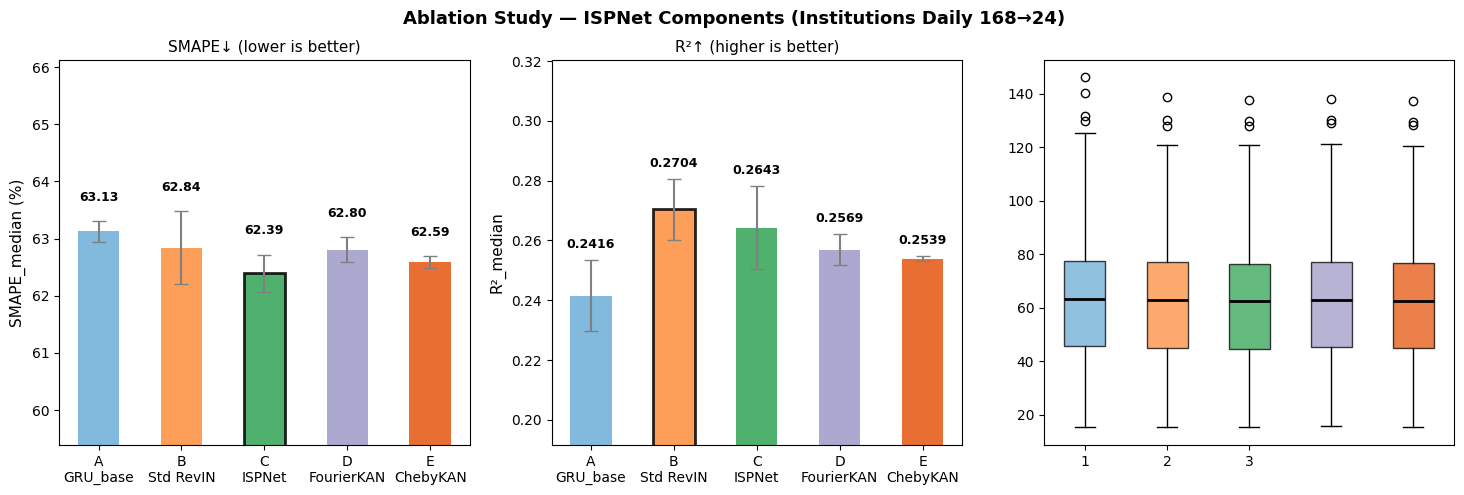

In [10]:
# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Ablation Study — ISPNet Components (Institutions Daily 168→24)",
             fontsize=13, fontweight="bold")

colors  = ["#6baed6", "#fd8d3c", "#31a354", "#9e9ac8", "#e6550d"]
xlabels = ["A\nGRU_base", "B\nStd RevIN", "C\nISPNet", "D\nFourierKAN", "E\nChebyKAN"]
x       = np.arange(len(VARIANTS))

# ── Bar chart: SMAPE median ──────────────────────────────────────────
ax = axes[0]
smape_means = [abl.loc[v["label"], "SMAPE_median"] for v in VARIANTS]
smape_stds  = [abl.loc[v["label"], "SMAPE_std"]    for v in VARIANTS]
bars = ax.bar(x, smape_means, color=colors, alpha=0.85, width=0.5,
              yerr=smape_stds, capsize=5, ecolor="gray", error_kw={"linewidth": 1.5})
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("SMAPE_median (%)", fontsize=11)
ax.set_title("SMAPE↓ (lower is better)", fontsize=11)
# Annotate values
for bar, val, err in zip(bars, smape_means, smape_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
# Highlight best
best_idx = int(np.argmin(smape_means))
bars[best_idx].set_edgecolor("black"); bars[best_idx].set_linewidth(2)
ax.set_ylim(min(smape_means) - 3, max(smape_means) + 3)

# ── Bar chart: R2 median ─────────────────────────────────────────────
ax = axes[1]
r2_means = [abl.loc[v["label"], "R2_median"] for v in VARIANTS]
r2_stds  = [abl.loc[v["label"], "R2_std"]    for v in VARIANTS]
bars = ax.bar(x, r2_means, color=colors, alpha=0.85, width=0.5,
              yerr=r2_stds, capsize=5, ecolor="gray", error_kw={"linewidth": 1.5})
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("R²_median", fontsize=11)
ax.set_title("R²↑ (higher is better)", fontsize=11)
for bar, val, err in zip(bars, r2_means, r2_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
best_idx = int(np.argmax(r2_means))
bars[best_idx].set_edgecolor("black"); bars[best_idx].set_linewidth(2)
ax.set_ylim(min(r2_means) - 0.05, max(r2_means) + 0.05)

# ── Box plot: SMAPE per-entity distribution ──────────────────────────
ax = axes[2]
box_data = []
for v in VARIANTS:
    # Average SMAPE per entity across seeds
    all_ent_smapes = pd.concat(
        [df.set_index("id_institution")["test_SMAPE"] for df in ablation_results[v["name"]]],
        axis=1
    ).mean(axis=1).values
    box_data.append(all_ent_smapes)

bp = ax.boxplot(box_data, patch_artist=True, widths=0.5,
                medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("SMAPE per entity (%)", fontsize=11)
ax.set_title("SMAPE distribution (283 entities)", fontsize=11)

# Legend
patches = [mpatches.Patch(color=c, label=v["label"].split(" — ")[1])
           for c, v in zip(colors, VARIANTS)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.03), frameon=False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(RESULTS_ROOT / "ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_ROOT / 'ablation_comparison.png'}")

In [ ]:
# ── Component contribution heatmap ───────────────────────────────────
# Shows which entities benefit most from mask-aware RevIN
df_base = pd.concat([df.set_index("id_institution")["test_SMAPE"]
                     for df in ablation_results["GRU_base"]], axis=1).mean(axis=1)
df_msk  = pd.concat([df.set_index("id_institution")["test_SMAPE"]
                     for df in ablation_results["ISPNet"]], axis=1).mean(axis=1)

improvement = (df_base - df_msk).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors_imp = ["#31a354" if v > 0 else "#de2d26" for v in improvement.values]
ax.bar(range(len(improvement)), improvement.values, color=colors_imp, alpha=0.8, width=1.0)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(improvement.mean(), color="#31a354", linewidth=1.5, linestyle="-",
           label=f"Mean improvement: {improvement.mean():.2f} pp")
ax.set_xlabel("Institution (sorted by improvement)", fontsize=11)
ax.set_ylabel("SMAPE improvement (pp)\nGRU_base − ISPNet", fontsize=11)
ax.set_title("Per-entity SMAPE improvement: GRU_base → ISPNet (Mask-Aware RevIN)", fontsize=12)
ax.legend(fontsize=10)

n_improved  = (improvement > 0).sum()
n_worsened  = (improvement <= 0).sum()
ax.text(0.02, 0.95, f"Improved: {n_improved}/{len(improvement)} entities ({100*n_improved/len(improvement):.0f}%)",
        transform=ax.transAxes, fontsize=10, va="top",
        color="#31a354", fontweight="bold")
ax.text(0.02, 0.87, f"Worsened: {n_worsened}/{len(improvement)} entities ({100*n_worsened/len(improvement):.0f}%)",
        transform=ax.transAxes, fontsize=10, va="top", color="#de2d26")

plt.tight_layout()
fig.savefig(RESULTS_ROOT / "ablation_per_entity_improvement.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_ROOT / 'ablation_per_entity_improvement.png'}")